In [ ]:
# # Autoencoder: Reconstructing Digits
# **Goal:** Train a simple autoencoder to reconstruct MNIST images, then tweak settings to see how quality changes.

# **Key ideas:** encoder → bottleneck (latent vector) → decoder, MSE loss, reconstruction quality.


In [ ]:

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cpu


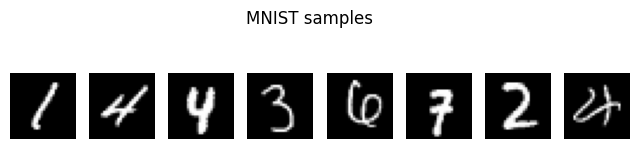

In [ ]:
BATCH_SIZE = 256

tf = transforms.ToTensor()  # scales to [0,1]
train_ds = datasets.MNIST(root="./data", train=True,  download=True, transform=tf)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# peek
imgs, _ = next(iter(train_loader))
plt.figure(figsize=(8,2))
for i in range(8):
    plt.subplot(1,8,i+1); plt.imshow(imgs[i,0], cmap="gray"); plt.axis("off")
plt.suptitle("MNIST samples")
plt.show()


In [ ]:
class AE(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        # Encoder
        self.enc = nn.Sequential(
            nn.Flatten(),                 # [B,1,28,28] -> [B,784]
            nn.Linear(784, 256), nn.ReLU(),# in the encoder and decoder hidden layers
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, latent_dim)    # [B, latent_dim]
        )
        # Decoder
        self.dec = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 784), nn.Sigmoid()  # only at the final output layer
        )

    def forward(self, x):
        z   = self.enc(x)                     # bottleneck (compressed representation)
        out = self.dec(z)                     # reconstructed vector [B,784]
        return out.view(-1, 1, 28, 28)        # reshape to image [B,1,28,28]


Epoch 1: loss=0.0658
Epoch 2: loss=0.0314
Epoch 3: loss=0.0242
Epoch 4: loss=0.0206
Epoch 5: loss=0.0179


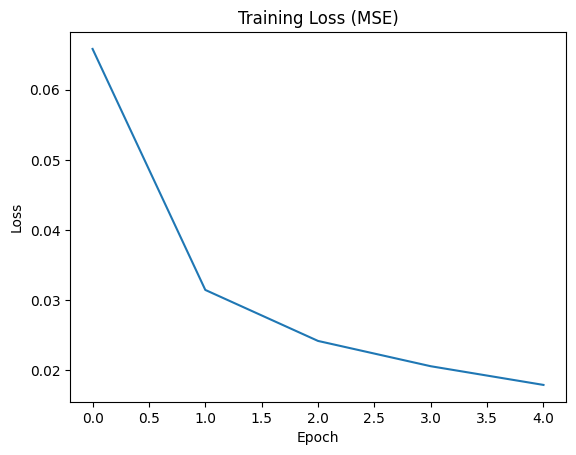

In [ ]:


model = AE(latent_dim=32).to(DEVICE)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 5
losses = []

for ep in range(EPOCHS):
    model.train()
    running = 0.0
    for xb, _ in train_loader:
        xb = xb.to(DEVICE)
        optimizer.zero_grad()
        xhat = model(xb)
        loss = criterion(xhat, xb)
        loss.backward()
        optimizer.step()
        running += loss.item() * xb.size(0)

    epoch_loss = running / len(train_loader.dataset)
    losses.append(epoch_loss)
    print(f"Epoch {ep+1}: loss={epoch_loss:.4f}")

plt.plot(losses); plt.title("Training Loss (MSE)"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.show()


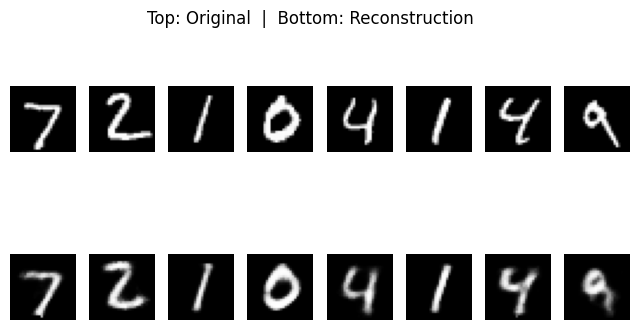

In [ ]:
model.eval()
xb, _ = next(iter(test_loader))
xb = xb.to(DEVICE)[:8]
with torch.no_grad():
    xhat = model(xb).cpu()
xb = xb.cpu()

plt.figure(figsize=(8,4))
for i in range(8):
    plt.subplot(2,8,i+1);      plt.imshow(xb[i,0],   cmap="gray"); plt.axis("off")
    plt.subplot(2,8,8+i+1);    plt.imshow(xhat[i,0], cmap="gray"); plt.axis("off")
plt.suptitle("Top: Original  |  Bottom: Reconstruction")
plt.show()


In [ ]:
# 🧩 TODO: Setup your training parameters
# -------------------------------
# Follow these simple rules:
# 1. Change the number of EPOCHS to 15
# 2. Set the BATCH_SIZE to 128
# 3. Choose a LATENT_DIM (compression size):
#    - Always pick a power of 2 (like 4, 8, 16, 32, or 64)
#    - Smaller numbers = more compression (blurry images)
#    - Bigger numbers  = less compression (clearer images)
# Modify Learning Rate